## Load libraries and file directories

In [1]:
import libstempo as T
import numpy as np
import libstempo.plot as LP, libstempo.toasim as LT
import os, glob, json

T.data_par = '/Users/blaze/PhD_work/SMBHB_proj/SMBHB_EM_vs_GW/SMBHB_population_injection/psars_narrowband/par/'
T.data_tim = '/Users/blaze/PhD_work/SMBHB_proj/SMBHB_EM_vs_GW/SMBHB_population_injection/psars_narrowband/tim/'



parfiles = sorted(glob.glob(T.data_par + '*.nb.par'))
timfiles = sorted(glob.glob(T.data_tim + '*.nb.tim'))

## Load original pulsars

In [2]:
# psr_list = []
# for parfile in os.listdir(T.data_par):
#     if parfile.endswith('.par'):
#         timfile = parfile.replace('.par', '.tim')
#         psr = T.tempopulsar(parfile = T.data_par + parfile,
#                             timfile = T.data_tim + timfile)
#         psr_list.append(psr)
#         # LP.plotres(psr)


# Indices to skip (already identified)
skip_indices = {
    48,  # J1802-2124 (stuck at 0 TOAs)
    }

log_path = '/Users/blaze/PhD_work/psr_load_log.txt'
psrs = []
with open(log_path, 'w') as log:
    for i, (p, t) in enumerate(zip(parfiles, timfiles)):
        if i in skip_indices:
            log.write(f"SKIPPED  [{i:02d}] {os.path.basename(p)}\n")
            log.flush()
            continue
        log.write(f"TRYING   [{i:02d}] {os.path.basename(p)}\n")
        log.flush()  # flush BEFORE loading so crash tells us exactly which file
        psr = T.tempopulsar(parfile=p, timfile=t, maxobs=60000)
        print(f"Loaded {psr.name}, index {i}")
        log.write(f"OK       [{i:02d}] {psr.name}, {psr.nobs} TOAs\n")
        log.flush()
        # LP.plotres(psr)
        psrs.append(psr)
print(f"\n✅ Successfully loaded {len(psrs)} pulsars. See log for details.")

[tempo2Util.C:396] Warning: [MISC1] Unknown parameter in par file:  DMDATA
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.

[observatory.C:271] Warning: Assuming site 'arecibo' means 'ao'
Loaded B1855+09, index 0

Loaded B1937+21, index 1

Loaded B1937+21ao, index 2

Loaded B1937+21gbt, index 3

Loaded B1953+29, index 4
Loaded J0023+0923, index 5

Loaded J0030+0451, index 6
Loaded J0340+4130, index 7
Loaded J0406+3039, index 8

Loaded J0437-4715, index 9
Loaded J0509+0856, index 10
Loaded J0557+1551, index 11
Loaded J0605+3757, index 12

Loaded J0610-2100, index 13

Loaded J0613-0200, index 14
Loaded J0614-3329, index 15
Loaded J0636+5128, index 16
Loaded J0645+5158, index 17
Loaded J0709+0458, index 18
Loaded J0740+6620, index 19
Loaded J0931-1902, index 20

Loaded J1012+5307, index 21
Loaded J1012-4235, index 22
Loaded J1022+1001, index 23
Loaded J1024-0719, index 24
Loaded J1125+7819, index 25
Loaded J1312+0051, index 26
Loaded J1453+1902, index 27
Loade

## Filtering and cleaning pulsars
Filter to pulsars with baselines longer than 3 years

In [3]:
def get_base_name(psrname):
    """Strip telescope suffix (ao, gbt, vla) from pulsar name."""
    for suffix in ['ao', 'gbt', 'vla', 'fast']:
        if psrname.endswith(suffix):
            return psrname[:-len(suffix)]
    return psrname

def filter_pulsars_15yr(psrs, min_baseline_years=3.0, verbose=True):
    from config import NOISEFILE
    with open(NOISEFILE, 'r') as f:
        params = json.load(f)

    noise_names = set([k.split('_')[0] for k in params.keys() if '_' in k])

    psrs_filtered = []
    for psr in psrs:
        base = get_base_name(psr.name)
        if base not in noise_names:
            if verbose:
                print(f"  No noise match for: {psr.name} (base: {base})")
            continue
        baseline_years = (psr.toas().max() - psr.toas().min()) / (365.25)
        if baseline_years >= min_baseline_years:
            psrs_filtered.append(psr)
        elif verbose:
            print(f"  Short baseline ({baseline_years:.1f} yr): {psr.name}")

    if verbose:
        print(f"\nFiltered: {len(psrs)} → {len(psrs_filtered)} pulsars")

    return psrs_filtered, params


# Global dict to store original stoas outside the psr object
original_stoas = {}

def get_clean_pulsars_and_tspan(psrs_filtered):
    """Get pulsars and calculate Tspan."""
    tmin = min(p.toas().min() for p in psrs_filtered)
    tmax = max(p.toas().max() for p in psrs_filtered)
    Tspan = (tmax - tmin) * 86400  # convert days to seconds

    # Save original stoas keyed by pulsar name
    for psr in psrs_filtered:
        if psr.name not in original_stoas:
            original_stoas[psr.name] = np.copy(psr.stoas[:])

    return psrs_filtered, Tspan

def reset_pulsars(psrs_filtered):
    """Reset all pulsars to original stoas between injections."""
    for psr in psrs_filtered:
        if psr.name in original_stoas:
            psr.stoas[:] = original_stoas[psr.name]

In [4]:
psrs_filtered, noise_params = filter_pulsars_15yr(psrs, min_baseline_years=3.0)
psrs_clean, Tspan_seconds = get_clean_pulsars_and_tspan(psrs_filtered)

  Short baseline (2.4 yr): J0614-3329

Filtered: 75 → 74 pulsars


## Simulate red & white noise in pulsars after zeroing the residuals

In [5]:
import matplotlib.pyplot as plt

def plot_residuals_raw(psr, title=""):
    """Plot stoas minus their mean, without triggering a tempo2 refit."""
    toas = psr.toas()  # MJD
    # raw residuals = stoas - fitted model, but without refitting
    # use the stored residuals array directly
    res = psr.residuals(updatebats=True, formresiduals=True)  # seconds
    plt.figure(figsize=(10, 3))
    plt.plot(toas, res * 1e6, '.', markersize=2)
    plt.xlabel("MJD")
    plt.ylabel("Residual (μs)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

noise_file = "15yr_noise.json"

# Load noise dictionary
with open(noise_file, 'r') as f:
    noise_dict = json.load(f)

def make_ideal_nofit(psr):
    """Zero residuals without refitting - avoids singular matrix issues with GLS timing models."""
    res = psr.residuals(updatebats=True, formresiduals=True)  # seconds
    print(f"  residuals range: {res.min()*1e6:.3f} to {res.max()*1e6:.3f} μs")
    print(f"  stoas range before: {psr.stoas.min()/ 86400.0:.7f} to {psr.stoas.max()/ 86400.0:.7f}")
    psr.stoas[:] -= res / 86400.0
    print(f"  stoas range after:  {psr.stoas.min()/ 86400.0:.7f} to {psr.stoas.max()/ 86400.0:.7f}")

def simulate_psr(psr, noise_dict, add_WN=True, add_RN=True, add_GWB=False, plot=False):
    psrname = psr.name
    basename = get_base_name(psrname)  # use this for noise dict lookups
    if plot:
        print(f"  [{psrname}] plotting original residuals...", flush=True)
        # plot_residuals_raw(psr)
        LP.plotres(psr)
        plt.show()
    print(f"  [{psrname}] zeroing residuals...", flush=True)
    make_ideal_nofit(psr)
    if plot:
        print(f"  [{psrname}] plotting ideal residuals...", flush=True)
        # plot_residuals_raw(psr, title="Ideal Residuals")
        LP.plotres(psr)
        plt.show()
    
    if add_RN:
        psr_keys = {k: v for k, v in noise_dict.items() if k.startswith(basename)}

        rn_log10_A_key = f"{basename}_red_noise_log10_A"
        rn_gamma_key   = f"{basename}_red_noise_gamma"

        if rn_log10_A_key in psr_keys and rn_gamma_key in psr_keys:
            log10_A = psr_keys[rn_log10_A_key]
            gamma   = psr_keys[rn_gamma_key]
            print(f"  [{psrname}] adding red noise...", flush=True)
            LT.add_rednoise(psr, 10**log10_A, gamma, components=30)
        if plot:
            print(f"  [{psrname}] plotting red noise added residuals...", flush=True)
            # plot_residuals_raw(psr, title="Residuals with Red Noise")
            LP.plotres(psr)
            plt.show()
        
    if add_WN:
        systems = set()
        for k in psr_keys:
            middle = k.replace(f"{basename}_", "")
            for suffix in ['_efac', '_log10_ecorr', '_log10_t2equad']:
                if middle.endswith(suffix):
                    systems.add(middle.replace(suffix, ""))

        for sys in systems:
            efac  = psr_keys.get(f"{basename}_{sys}_efac", 1.0)
            equad = 10**psr_keys.get(f"{basename}_{sys}_log10_t2equad", -100)
            ecorr = 10**psr_keys.get(f"{basename}_{sys}_log10_ecorr", -100)

            try:
                flag_vals = psr.flagvals('f')
                mask = np.array([sys in fv for fv in flag_vals])
            except:
                mask = np.ones(psr.nobs, dtype=bool)

            if mask.sum() == 0:
                continue
            print(f"  [{psrname}] white noise for {sys} ({mask.sum()} TOAs)...", flush=True)
            LT.add_efac(psr, efac, flagid='f', flags=sys)
            LT.add_equad(psr, equad, flagid='f', flags=sys)
            LT.add_jitter(psr, ecorr, flagid='f', flags=sys)
    
    # if add_GWB:

    if plot:
        print(f"[{psrname}] plotting final residuals with all noise...", flush=True)
        # plot_residuals_raw(psr, title="Final Residuals with All Noise")
        LP.plotres(psr)
        plt.show()

    return psr

In [52]:
for i, psr in enumerate(psrs_clean):
    if i == 1:
        print(f"Simulating {psr.name} with plots...")
        simulate_psr(psr, noise_dict, plot=False)
    else:
        simulate_psr(psr, noise_dict)
    print(f"Simulated {psr.name}")

  [B1855+09] zeroing residuals...
  residuals range: -2454.713 to 2818.120 μs
  stoas range before: 0.6175779 to 0.6834626
  stoas range after:  0.6175779 to 0.6834626
  [B1855+09] adding red noise...
  [B1855+09] white noise for 430_PUPPI (1185 TOAs)...
  [B1855+09] white noise for 430_ASP (390 TOAs)...
  [B1855+09] white noise for L-wide_PUPPI (5005 TOAs)...
  [B1855+09] white noise for L-wide_ASP (1178 TOAs)...
Simulated B1855+09
Simulating B1937+21 with plots...
  [B1937+21] zeroing residuals...
  residuals range: -32.890 to 32.448 μs
  stoas range before: 0.6165172 to 0.6836242
  stoas range after:  0.6165172 to 0.6836242
  [B1937+21] adding red noise...
  [B1937+21] white noise for Rcvr1_2_GASP (1069 TOAs)...
  [B1937+21] white noise for S-wide_PUPPI (2251 TOAs)...
  [B1937+21] white noise for L-wide_ASP (452 TOAs)...
  [B1937+21] white noise for Rcvr_800_GASP (586 TOAs)...
  [B1937+21] white noise for L-wide_PUPPI (4133 TOAs)...
  [B1937+21] white noise for Rcvr_800_GUPPI (7140 

In [7]:
import numpy as np

def diagnose_noise_injection(psr, noise_dict):
    """Verify each noise injection step with μs-precision tracking."""
    psrname = psr.name
    basename = get_base_name(psrname)
    psr_keys = {k: v for k, v in noise_dict.items() if k.startswith(basename)}

    def snapshot(label, stoas_ref=None):
        stoas = np.array(psr.stoas[:], dtype=np.float64)
        res_rms = float(np.std(psr.residuals(updatebats=True, formresiduals=True))) * 1e6
        if stoas_ref is not None:
            delta_us = (stoas - stoas_ref) * 86400 * 1e6
            delta_str = f"{delta_us.std():>10.4f} μs rms change"
        else:
            delta_str = f"{'---':>10}"
        return {"label": label, "stoas": stoas.copy(), "res_rms": res_rms, "delta_str": delta_str}

    stages = []

    # Stage 0: original
    stages.append(snapshot("0_original"))

    # Stage 1: make ideal
    make_ideal_nofit(psr)
    stages.append(snapshot("1_ideal", stages[-1]["stoas"]))

    # Stage 2: red noise
    rn_log10_A = psr_keys.get(f"{basename}_red_noise_log10_A")
    rn_gamma   = psr_keys.get(f"{basename}_red_noise_gamma")
    if rn_log10_A and rn_gamma:
        LT.add_rednoise(psr, 10**rn_log10_A, rn_gamma, components=30)
    stages.append(snapshot("2_after_red_noise", stages[-1]["stoas"]))

    # Stage 3: white noise
    systems = set()
    for k in psr_keys:
        middle = k.replace(f"{basename}_", "")
        for suffix in ['_efac', '_log10_ecorr', '_log10_t2equad']:
            if middle.endswith(suffix):
                systems.add(middle.replace(suffix, ""))

    for sys in systems:
        efac  = psr_keys.get(f"{basename}_{sys}_efac", 1.0)
        equad = 10**psr_keys.get(f"{basename}_{sys}_log10_t2equad", -100)
        ecorr = 10**psr_keys.get(f"{basename}_{sys}_log10_ecorr", -100)

        try:
            mask = np.array([sys in fv for fv in psr.flagvals('f')])
        except:
            mask = np.ones(psr.nobs, dtype=bool)

        if mask.sum() == 0:
            continue

        LT.add_efac(psr, efac, flagid='f', flags=sys)
        LT.add_equad(psr, equad, flagid='f', flags=sys)
        LT.add_jitter(psr, ecorr, flagid='f', flags=sys)

    stages.append(snapshot("3_after_white_noise", stages[-1]["stoas"]))

    # Print table
    print(f"\nPulsar: {psrname}")
    print(f"{'Stage':<25} {'residuals_rms':>15} {'stoas_change':>20}")
    print("-" * 62)
    for s in stages:
        print(f"{s['label']:<25} {s['res_rms']:>13.4f} μs   {s['delta_str']}")

    return stages

In [8]:
for psr in psrs: 
    diagnose_noise_injection(psr, noise_dict)


  residuals range: -82.872 to 93.242 μs
  stoas range before: 0.6175779 to 0.6834626
  stoas range after:  0.6175779 to 0.6834626

Pulsar: B1855+09
Stage                       residuals_rms         stoas_change
--------------------------------------------------------------
0_original                       6.4965 μs          ---
1_ideal                          0.1842 μs       6.4932 μs rms change
2_after_red_noise                0.8272 μs       0.7912 μs rms change
3_after_white_noise              5.9772 μs       5.9236 μs rms change
  residuals range: -18.483 to 13.958 μs
  stoas range before: 0.6165172 to 0.6836242
  stoas range after:  0.6165172 to 0.6836242

Pulsar: B1937+21
Stage                       residuals_rms         stoas_change
--------------------------------------------------------------
0_original                       5.1623 μs          ---
1_ideal                          0.1830 μs       5.1677 μs rms change
2_after_red_noise                9.5476 μs       9.5457 μs r

## Adding in the SMBHB population

In [77]:
from SMBHB_pop_synth import precompute_amplitudes
import finufft
from signal_injection import _topk_indices_from_amplitudes
import os

def inject_population_nufft(psrs, population,
                             verbose=False, eps=1e-6,
                             cache_precomputed_amplitudes=True,
                             track_contributors=False,
                             top_k_per_pulsar=20,
                             top_k_global=50,
                             contributor_chunk_size=500_000,
                             contributor_summary=None):
    """
    Inject SMBHB population via NUFFT type-3 (no frequency quantisation error).

    Uses finufft.nufft1d3:
        f(x_j) = sum_k c_k * exp(i * s_k * x_j)

    where:
        x_j = t_j - t[0]          (TOA times, non-uniform, in seconds)
        s_k = 2π f_k              (source frequencies, non-uniform, in rad/s)
        c_k = (C_k - i S_k) / 2  (complex amplitude, see derivation below)

    Derivation
    ----------
    r(t) = sum_k A_k sin(2π f_k t_rel + φ0_k) + B_k cos(2π f_k t_rel + φ0_k)

    Expanding with phi0:
        S_k = A_k cos(φ0) - B_k sin(φ0)   [coeff of sin(2π f_k t_rel)]
        C_k = A_k sin(φ0) + B_k cos(φ0)   [coeff of cos(2π f_k t_rel)]

    Writing in complex form using e^{isx} = cos(sx) + i sin(sx):
        r = Re[ sum_k (C_k - i S_k) * e^{i 2π f_k t_rel} ]

    For real output we also need the conjugate (negative frequency) term:
        r = Re[ sum_k (C_k - i S_k) * e^{+i 2π f_k t_rel}
                    + (C_k + i S_k) * e^{-i 2π f_k t_rel} ] / 2

    Using nufft1d3 with only positive frequencies and dividing by 2:
        c_k = (C_k - i S_k) / 2
        r = 2 * Re[ nufft1d3(x, s, c) ]

        No grid, no quantisation — exact to NUFFT tolerance (eps).

                Optional amplitude precompute controls:
                    - cache_precomputed_amplitudes: if False, amp_A/B generated during
                        this call are removed after each pulsar to reduce peak memory.
                    - track_contributors: track per-pulsar and global top contributors
                        by amplitude proxy A^2 + B^2.
                    - top_k_per_pulsar: number of binaries tracked per pulsar.
                    - top_k_global: number of globally ranked binaries returned.
                    - contributor_chunk_size: chunk size for top-k tracking, controls
                        memory use while scanning A/B arrays.
                    - contributor_summary: optional dict to populate with tracking output.
    """
    f_arr    = population.f
    phi0_arr = population.phi0

    # Source frequencies in rad/s — these are the NUFFT "s" points
    # No gridding, no rounding — exact frequencies
    s_arr = 2 * np.pi * f_arr   # (N,) rad/s

    # phi0 rotation: same for all pulsars (source property)
    cos_phi0 = np.cos(phi0_arr)
    sin_phi0 = np.sin(phi0_arr)

    per_pulsar_top = {}
    contributor_candidates = set()

    for psr in psrs:
        psr_name = psr.name
        computed_here = False
        if psr_name not in population.amp_A:
            precompute_amplitudes(population, psr)
            computed_here = True

        A_arr = population.amp_A[psr_name]
        B_arr = population.amp_B[psr_name]

        if track_contributors:
            idx_top, score_top = _topk_indices_from_amplitudes(
                A_arr,
                B_arr,
                k=top_k_per_pulsar,
                chunk_size=contributor_chunk_size,
            )
            contributor_candidates.update(idx_top.tolist())
            per_pulsar_top[psr_name] = {
                'indices': idx_top.tolist(),
                'amp2': score_top.tolist(),
            }

        # phi0 rotation
        S = A_arr * cos_phi0 - B_arr * sin_phi0   # sin(2π f t_rel) coeff
        C = A_arr * sin_phi0 + B_arr * cos_phi0   # cos(2π f t_rel) coeff

        # Complex amplitudes: c_k = (C_k - i S_k) / 2
        c = (C - 1j * S) / 2   # (N,)

        # TOA times relative to first TOA — the NUFFT "x" points
        t_sec = np.asarray(psr.stoas, dtype=np.float64) * 86400.0  # days -> seconds
        x     = t_sec - t_sec[0]   # relative times in seconds  

        # nufft1d3: f(x_j) = sum_k c_k * exp(i * s_k * x_j)
        # isign=+1 matches our e^{+i 2π f t} convention
        x      = np.ascontiguousarray(x,     dtype=np.float64)
        s_nufft = np.ascontiguousarray(s_arr, dtype=np.float64)
        c_nufft = np.ascontiguousarray(c,     dtype=np.complex128)

        f_out = finufft.nufft1d3(s_nufft, c_nufft, x, isign=+1, eps=eps)

        # Multiply by 2: we only passed positive frequencies,
        # negative frequencies contribute equal real part
        time_change = 2 * np.real(f_out)

        if verbose:
            print(f"  {psr_name}: RMS = {time_change.std()*1e9:.3f} ns")

        psr.stoas[:] += time_change / 86400.0  # seconds -> days


        if computed_here and not cache_precomputed_amplitudes:
            population.amp_A.pop(psr_name, None)
            population.amp_B.pop(psr_name, None)

    if track_contributors:
        global_top = {'indices': [], 'score': []}
        if contributor_candidates:
            candidate_idx = np.asarray(sorted(contributor_candidates), dtype=np.int64)
            global_score = np.zeros(candidate_idx.size, dtype=np.float64)

            for psr in psrs:
                psr_name = psr.name
                A_c = population.amp_A[psr_name][candidate_idx]
                B_c = population.amp_B[psr_name][candidate_idx]
                global_score += A_c * A_c + B_c * B_c

            k_glob = min(max(int(top_k_global), 0), candidate_idx.size)
            if k_glob > 0:
                keep = np.argpartition(global_score, global_score.size - k_glob)[-k_glob:]
                order = np.argsort(global_score[keep])[::-1]
                keep_ord = keep[order]
                global_top = {
                    'indices': candidate_idx[keep_ord].tolist(),
                    'score': global_score[keep_ord].tolist(),
                }

        summary = {
            'score_definition': 'A^2 + B^2 per pulsar; global score is sum over pulsars',
            'n_binaries_total': int(len(population.f)),
            'n_candidates_global': int(len(contributor_candidates)),
            'per_pulsar_top_k': int(top_k_per_pulsar),
            'global_top_k': int(top_k_global),
            'per_pulsar': per_pulsar_top,
            'global': global_top,
        }

        if contributor_summary is not None:
            contributor_summary.clear()
            contributor_summary.update(summary)
        else:
            try:
                population.contributor_summary = summary
            except Exception:
                pass

    return psrs

In [53]:
from SMBHB_pop_synth import chosen_population
population = chosen_population(n_binaries=1, chirp_mass_msun=1e10, gw_frequency=1e-8)

In [24]:
population[0]

PopulationArrays(f=array([1.e-07]), Mc=array([1.e+11]), Mtot=array([1.64375183e+11]), D_comov=array([1973.17453397]), z=array([0.5]), h0=array([1.83074751e-12]), ra=array([0.]), dec=array([0.]), psi=array([0.]), iota=array([0.]), phi0=array([0.]), amp_A={'B1855+09': array([3.40813214e-06]), 'B1937+21': array([2.75880758e-06]), 'B1937+21ao': array([2.75880759e-06]), 'B1937+21gbt': array([2.75880758e-06]), 'B1953+29': array([1.7523057e-06]), 'J0023+0923': array([-2.61739018e-06]), 'J0030+0451': array([2.41218141e-06]), 'J0340+4130': array([-3.16765776e-07]), 'J0406+3039': array([1.541674e-06]), 'J0437-4715': array([-5.21250698e-07]), 'J0509+0856': array([3.36504889e-06]), 'J0557+1551': array([2.50579331e-06]), 'J0605+3757': array([6.9585638e-07]), 'J0610-2100': array([2.07366408e-06]), 'J0613-0200': array([2.73285212e-06]), 'J0636+5128': array([-6.20966485e-07]), 'J0645+5158': array([-6.64397323e-07]), 'J0709+0458': array([2.01763374e-06]), 'J0740+6620': array([-1.76001151e-06]), 'J0931-

In [15]:
update = inject_population_nufft(psrs_clean, population[0])

  B1855+09: RMS = 118.408 ns


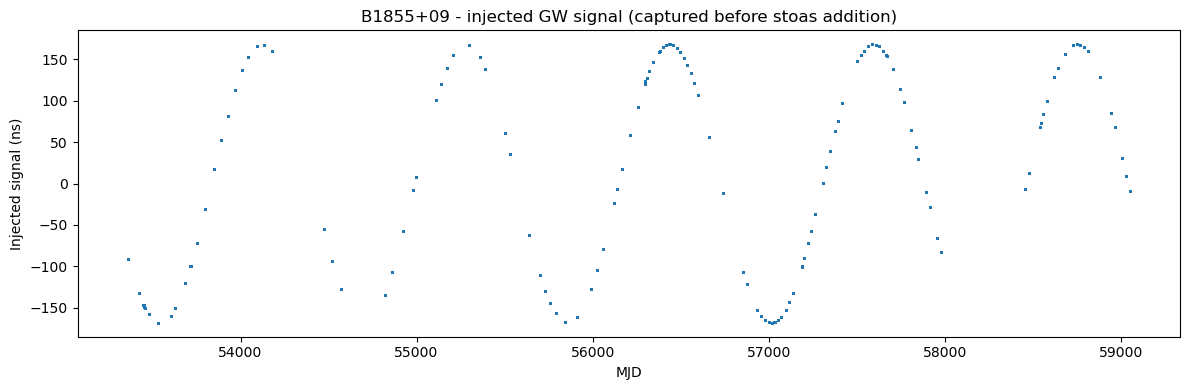

In [78]:
captured_signals = {}

def inject_population_nufft_debug(psrs, population, eps=1e-6, **kwargs):
    f_arr    = population.f
    phi0_arr = population.phi0
    s_arr    = 2 * np.pi * f_arr
    cos_phi0 = np.cos(phi0_arr)
    sin_phi0 = np.sin(phi0_arr)

    for psr in psrs:
        psr_name = psr.name
        if psr_name not in population.amp_A:
            precompute_amplitudes(population, psr)

        A_arr = population.amp_A[psr_name]
        B_arr = population.amp_B[psr_name]

        S = A_arr * cos_phi0 - B_arr * sin_phi0
        C = A_arr * sin_phi0 + B_arr * cos_phi0
        c = (C - 1j * S) / 2

        t_sec  = np.asarray(psr.stoas, dtype=np.float64) * 86400.0
        x      = t_sec - t_sec[0]
        x      = np.ascontiguousarray(x,     dtype=np.float64)
        s_nufft = np.ascontiguousarray(s_arr, dtype=np.float64)
        c_nufft = np.ascontiguousarray(c,     dtype=np.complex128)

        f_out = finufft.nufft1d3(s_nufft, c_nufft, x, isign=+1, eps=eps)
        time_change = 2 * np.real(f_out)  # seconds

        # Capture before adding to stoas
        captured_signals[psr_name] = {
            'toas_mjd':    psr.toas().copy(),
            'time_change': time_change.copy(),  # seconds
        }

        print(f"  {psr_name}: RMS = {time_change.std()*1e9:.3f} ns")
        psr.stoas[:] += time_change / 86400.0

# Run
inject_population_nufft_debug(psrs_clean[:1], population[0])

# Plot directly from captured signal - no float64 cancellation
psr_name = psrs_clean[0].name
sig = captured_signals[psr_name]

plt.figure(figsize=(12, 4))
plt.plot(sig['toas_mjd'], sig['time_change'] * 1e9, '.', markersize=2)
plt.xlabel("MJD")
plt.ylabel("Injected signal (ns)")
plt.title(f"{psr_name} - injected GW signal (captured before stoas addition)")
plt.tight_layout()
plt.show()

In [73]:
psr = psrs_clean[0]
stoas_before = np.array(psr.stoas[:], dtype=np.float64) * 86400  # days -> seconds

inject_population_nufft([psr], population[0])

stoas_after = np.array(psr.stoas[:], dtype=np.float64) * 86400  # days -> seconds
time_change = stoas_after - stoas_before

print(f"time_change RMS: {time_change.std()*1e6:.3f} μs")
print(f"time_change max: {time_change.max()*1e6:.3f} μs")
print(f"Expected from A/B: ~{2.598e-7 * 1e6:.3f} μs")

  B1855+09: RMS = 118.408 ns
time_change RMS: 0.000 μs
time_change max: 0.000 μs
Expected from A/B: ~0.260 μs
